# EXAMEN FINAL — Análisis de Emisiones de CO2
**Curso:** Fundamentos de Python  
**Universidad:** UMCA  
**Docente:** Ing. Andrés Mena Abarca

**Estudiante:** Kevin Nuñez Jaimes
## Archivo de trabajo
`Estimaciones_Emisiones_Dioxido_Carbono.csv`

## Propósito
Este examen final integra los contenidos principales del curso: carga y exploración de datos, uso de listas, diccionarios, ciclos, funciones, análisis con `pandas`, visualización con `matplotlib` y comunicación de hallazgos con evidencia.


## Idea central del caso
El dataset contiene emisiones de CO2 de varios países entre 1975 y 2017. Cada fila representa una observación para un país, un año y un tipo de medición.

Hay **dos tipos de emisión**:
- `Emisiones (kilotoneladas metricas de dioxido de carbono)`
- `Emisiones per capita (toneladas metricas de dioxido de carbono)`

### Atención
Estas dos métricas **no significan lo mismo**. Parte del examen consiste en distinguirlas correctamente y evitar comparaciones equivocadas.


## Entregables esperados
1. Código funcional y ordenado.
2. Evidencia de comprensión del dataset.
3. Uso de **4 funciones obligatorias** creadas por ti.
4. Resolución de un bloque con Python base.
5. Resolución de un bloque con `pandas`.
6. Dos gráficos correctamente rotulados.
7. Un informe final crítico con evidencia numérica.


## Distribución de puntaje (100 puntos)
- **Bloque 1 — Comprensión del dataset:** 10 pts
- **Bloque 2 — Normalización y preparación analítica:** 10 pts
- **Bloque 3 — Resolución con Python base:** 22 pts
- **Bloque 4 — Análisis con pandas:** 28 pts
- **Bloque 5 — Visualización con matplotlib:** 10 pts
- **Bloque 6 — Informe final crítico:** 20 pts


## Rúbrica por niveles de desempeño

### Niveles
- **No logrado:** no cumple el objetivo central del bloque o presenta errores conceptuales clave.
- **Inicial:** hay intento válido, pero faltan componentes esenciales o hay confusiones importantes.
- **Intermedio:** resuelve correctamente la mayor parte, con interpretación suficiente.
- **Logrado:** resuelve con precisión, explica bien y conecta el resultado con el análisis.

### Criterio general
El examen no se califica solo por obtener un número correcto. También se valora el razonamiento, el uso adecuado de la herramienta y la capacidad de interpretar.


In [1]:
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import pandas as pd

ARCHIVO = "Estimaciones_Emisiones_Dioxido_Carbono.csv"


---
## Bloque 1 — Comprensión del dataset (10 pts)

### Objetivo
Comprender la estructura real del archivo antes de empezar a analizar.

### Debes hacer exactamente esto
1. Cargar el CSV en un DataFrame llamado `df_raw`.
2. Mostrar:
   - `df_raw.shape`
   - lista de columnas
   - `df_raw.head(5)`
   - años disponibles
   - tipos de emisión disponibles
   - cantidad de países únicos
3. Escribir un texto breve de **4 a 6 líneas** respondiendo:
   - qué representa una fila del dataset,
   - qué diferencia conceptual existe entre `emisiones_totales` y `emisiones_per_capita`,
   - por qué sería incorrecto compararlas como si fueran exactamente lo mismo.

### Nivel esperado
- **No logrado:** carga incompleta o confusión sobre la estructura del archivo.
- **Inicial:** identifica elementos básicos, pero no explica bien la diferencia entre métricas.
- **Intermedio:** describe correctamente la estructura y distingue ambas métricas.
- **Logrado:** además de distinguirlas, explica por qué esa diferencia afecta el análisis.


In [2]:
# 1.1 Carga el archivo en un DataFrame llamado df_raw

df_raw = pd.read_csv(ARCHIVO)



In [3]:
# 1.2 Muestra shape, columnas, head(5), años disponibles, tipos de emisión y países únicos
df_raw = pd.read_csv(ARCHIVO)
# 1.2 Exploración con nombres reales
print(f"Los datos totales son: {df_raw.shape[0]} filas y {df_raw.shape[1]} columnas")
print("*" * 100)
print(f"Los nombres de las columnas son los siguientes: {df_raw.columns.tolist()}")
print("*" * 100)
print(f"Los primeros 5 registros del DataFrame son:\n {df_raw.head(5)}")

años = df_raw['Year'].unique()
tipos = df_raw['Type'].unique().tolist()
paises = df_raw['Country'].nunique()
print("*" * 100)
print(f"Los Años disponibles son: {min(años)} - {max(años)}")
print("*" * 100)
print(f"Los tipos de emisión registrados son:\n {tipos}")
print("*" * 100)
print(f"Los países únicos son: {paises}")

Los datos totales son: 2132 filas y 4 columnas
****************************************************************************************************
Los nombres de las columnas son los siguientes: ['Country', 'Year', 'Type', 'Value']
****************************************************************************************************
Los primeros 5 registros del DataFrame son:
    Country  Year                                               Type     Value
0  Albania  1975  Emisiones (kilotoneladas metricas de dioxido d...  4338.334
1  Albania  1985  Emisiones (kilotoneladas metricas de dioxido d...  6929.926
2  Albania  1995  Emisiones (kilotoneladas metricas de dioxido d...  1848.549
3  Albania  2005  Emisiones (kilotoneladas metricas de dioxido d...  3825.184
4  Albania  2010  Emisiones (kilotoneladas metricas de dioxido d...  3930.295
****************************************************************************************************
Los Años disponibles son: 1975 - 2017
**************

### Explicación conceptual del Bloque 1
Escribe aquí tu texto de 4 a 6 líneas.



   - ¿qué representa una fila del dataset?

   El dataset representa las emisiones de CO2 vinculadas a un país, año y una métrica de medición particular (total o per cápita), entonces de esta forma podemos realizar el análisis
   respectivo y calcular el país con mayor emisión o cuál país tiene menor emisión. 
   - ¿qué diferencia conceptual existe entre `emisiones_totales` y `emisiones_per_capita`?

   La diferencia conceptual principal entre emisiones totales y emisiones per cápita radica en el enfoque de medición (volumen absoluto vs. promedio individual), esto quiere decir que las emisiones totales miden la suma total de gases emitidos en un país y emisiones Per Cápita (por persona) miden el promedio de emisiones generado por cada persona en una población. 
   - ¿por qué sería incorrecto compararlas como si fueran exactamente lo mismo.?

   Como se menciona anteriormente emisiones totales nos indican la emisión total registrada por país, pero la emisión per capita se refiere al promedio de emisión que genera cada persona en su país.


---
## Bloque 2 — Normalización y preparación analítica (10 pts)

### Objetivo
Transformar la estructura del dataset a una forma más legible para el análisis, sin alterar el contenido original de los datos.

### Nombres obligatorios
Debes crear:
- `df_trabajo`
- `df_totales_es`
- `df_per_capita_es`
- función `renombrar_columnas_es(df)`
- función `separar_por_tipo(df, tipo_emision)`

### Requisitos exactos
1. Crear una función `renombrar_columnas_es(df)` que retorne una copia del DataFrame con estas columnas:
   - `pais`
   - `anio`
   - `tipo_emision`
   - `valor`
2. Aplicar esa función y guardar el resultado en `df_trabajo`.
3. Crear una función `separar_por_tipo(df, tipo_emision)` que filtre un DataFrame según el valor exacto de `tipo_emision`.
4. Crear:
   - `df_totales_es`
   - `df_per_capita_es`
5. Mostrar evidencia de que la preparación fue correcta:
   - columnas de `df_trabajo`
   - primeras 5 filas de `df_trabajo`
   - shape de `df_totales_es`
   - shape de `df_per_capita_es`
6. Escribir una reflexión breve de **2 a 3 líneas** respondiendo:
   - por qué renombrar columnas al español puede ayudar al análisis,
   - por qué separar emisiones totales y per cápita es necesario antes de comparar.

### Nota pedagógica
En este bloque no se espera corregir errores del archivo, porque el dataset original ya es consistente. Se espera que prepares una versión más clara para trabajar y que evites mezclar métricas distintas.

### Nivel esperado
- **No logrado:** no renombra correctamente las columnas o no separa bien los dos tipos de emisión.
- **Inicial:** renombra parcialmente o separa con errores menores, pero la intención del proceso es visible.
- **Intermedio:** renombra correctamente, separa bien ambos subconjuntos y muestra evidencia básica de que el trabajo quedó listo para analizar.
- **Logrado:** además de lo anterior, explica con claridad por qué la normalización semántica y la separación por métrica mejoran la lectura y reducen errores analíticos.


In [4]:
# 2.1 Crea aquí la función renombrar_columnas_es(df) y la función separar_por_tipo(df, tipo_emision)
def renombrar_columnas_es(df):
    dict_nombres = {
        'Country': 'pais',
        'Year': 'anio',
        'Type': 'tipo_emision', # Ahora mapeamos 'Type' correctamente
        'Value': 'valor'
    }
    return df.rename(columns=dict_nombres).copy()

def separar_por_tipo(df, tipo_emision):
    return df[df['tipo_emision'] == tipo_emision].copy()

In [5]:
# 2.2 Crea aquí df_trabajo, df_totales_es y df_per_capita_es
df_trabajo = renombrar_columnas_es(df_raw)
tipo_total = 'Emisiones (kilotoneladas metricas de dioxido de carbono)'
tipo_pc = 'Emisiones per capita (toneladas metricas de dioxido de carbono)'
df_totales_es = separar_por_tipo(df_trabajo, tipo_total)
df_per_capita_es = separar_por_tipo(df_trabajo, tipo_pc)

In [6]:
# 2.3 Muestra aquí evidencia de que la preparación fue correcta
print(f"Columnas df_trabajo: {df_trabajo.columns.tolist()}")
print("*" * 100)
print(f"Primeras 5 filas de df_trabajo:\n{df_trabajo.head(5)}")
print("*" * 100)
print(f"Shape de df_totales_es: {df_totales_es.shape}")
print(f"Shape de df_per_capita_es: {df_per_capita_es.shape}")


Columnas df_trabajo: ['pais', 'anio', 'tipo_emision', 'valor']
****************************************************************************************************
Primeras 5 filas de df_trabajo:
      pais  anio                                       tipo_emision     valor
0  Albania  1975  Emisiones (kilotoneladas metricas de dioxido d...  4338.334
1  Albania  1985  Emisiones (kilotoneladas metricas de dioxido d...  6929.926
2  Albania  1995  Emisiones (kilotoneladas metricas de dioxido d...  1848.549
3  Albania  2005  Emisiones (kilotoneladas metricas de dioxido d...  3825.184
4  Albania  2010  Emisiones (kilotoneladas metricas de dioxido d...  3930.295
****************************************************************************************************
Shape de df_totales_es: (1066, 4)
Shape de df_per_capita_es: (1066, 4)


### Reflexión corta del Bloque 2
Escribe aquí tu reflexión de 2 a 3 líneas.

Se ha creado la función para que se cambien los nombres en inglés del csv y ponerlo en español para que sea más comprensible, además se ha creado otra función para separar por tipo de emisión y así obtener el dato real por aparte y que sea más fácil de comprenderlo.

---
## Bloque 3 — Resolución con Python base (22 pts)

### Objetivo
Resolver parte del análisis usando listas, diccionarios, ciclos, condicionales y funciones, sin depender de agregaciones de `pandas`.

### Regla del bloque
En este bloque **no uses** `groupby` ni agregaciones avanzadas de `pandas` para obtener las respuestas principales.

### Nombres obligatorios
Debes crear:
- `registros_totales`
- función `resumen_pais(registros, pais)`
- `prediccion_inicial`
- `paises_ordenados`
- `valor_maximo_total`
- `pais_valor_maximo_total`
- `anio_max_costa_rica`
- `reporte_centroamerica_base`

### Activación de hipótesis
Antes de calcular, escribe en `prediccion_inicial` una oración corta respondiendo:
“¿Qué país crees que tendrá el mayor valor registrado en emisiones totales y por qué?”

### La función `resumen_pais(registros, pais)` debe retornar un diccionario con estas claves exactas
- `pais`
- `cantidad_registros`
- `anio_min`
- `anio_max`
- `valor_max`

### Resuelve exactamente estas tareas con Python base
1. Convertir `df_totales_es` en una lista de diccionarios llamada `registros_totales`.
2. Obtener una lista alfabética de países únicos y guardarla en `paises_ordenados`.
3. Obtener el valor máximo global de emisiones totales y guardarlo en `valor_maximo_total`.
4. Obtener el país asociado a ese valor y guardarlo en `pais_valor_maximo_total`.
5. Obtener el año en que Costa Rica alcanza su mayor emisión total y guardarlo en `anio_max_costa_rica`.
6. Construir `reporte_centroamerica_base` para estos países:
   - `Costa Rica`
   - `Guatemala`
   - `Honduras`
   - `El Salvador`
   - `Nicaragua`

El formato esperado de `reporte_centroamerica_base` es una **lista de diccionarios** con estas claves exactas:
- `anio`
- `total_por_anio`

### Cierre del bloque
Escribe **2 a 3 líneas** comparando tu predicción inicial con la evidencia obtenida.

### Nivel esperado
- **No logrado:** no resuelve la lógica esencial o depende indebidamente de `pandas`.
- **Inicial:** resuelve fragmentos, pero con errores en acumulación, filtrado o estructura.
- **Intermedio:** responde correctamente la mayoría de tareas y construye el reporte base.
- **Logrado:** domina la lógica base y contrasta su intuición con la evidencia de forma clara.


In [7]:
# 3.1 Escribe aquí tu prediccion_inicial y luego crea registros_totales a partir de df_totales_es
prediccion_inicial = "Considero que Estados Unidos va ser el país con mayor emisión"

registros_totales = df_totales_es.to_dict(orient='records')

# 3.3 Tareas con Python base (SIN groupby)
# Para evitar la notación científica al imprimir, usamos f-strings con formato de millares
print(f"Predicción inicial: {prediccion_inicial}")
print("*" * 100)

# Buscamos el máximo global y su país manualmente
valor_maximo_total = 0
pais_valor_maximo_total = ""

for registro in registros_totales:
    if registro['valor'] > valor_maximo_total:
        valor_maximo_total = registro['valor']
        pais_valor_maximo_total = registro['pais']

# Imprimimos el resultado con formato numérico legible (,:f)
print(f"El país con mayor emisión detectado es: {pais_valor_maximo_total}")
print(f"Valor máximo registrado: {valor_maximo_total:,.2f} kt")

Predicción inicial: Considero que Estados Unidos va ser el país con mayor emisión
****************************************************************************************************
El país con mayor emisión detectado es: China
Valor máximo registrado: 9,257,933.90 kt


In [8]:
# 3.2 Crea aquí la función resumen_pais(registros, pais)
def resumen_pais(registros, nombre_pais):
    filtro = [r for r in registros if r['pais'] == nombre_pais]
    if not filtro:
        return None 
    lista_anios = [r['anio'] for r in filtro]
    lista_valores = [r['valor'] for r in filtro]
    return {
        'pais': nombre_pais,
        'cantidad_registros': len(filtro),
        'anio_min': min(lista_anios),
        'anio_max': max(lista_anios),
        'valor_max': max(lista_valores)
    }
resultado = resumen_pais(registros_totales, "Costa Rica")
print(f"País: {resultado['pais']}")
print(f"Máximo histórico: {resultado['valor_max']:,.2f}")

País: Costa Rica
Máximo histórico: 7,584.41


In [9]:
# 3.3 Resuelve aquí las tareas solicitadas con Python base
registros_totales = df_totales_es.to_dict(orient='records')
paises_ordenados = sorted(list(set([r['pais'] for r in registros_totales])))
valor_maximo_total = max([r['valor'] for r in registros_totales])
pais_valor_maximo_total = [r['pais'] for r in registros_totales if r['valor'] == valor_maximo_total][0]
anio_max_costa_rica = max([r['anio'] for r in registros_totales if r['pais'] == "Costa Rica"])
print(f"Países ordenados alfabéticamente:\n {paises_ordenados}")
print(f"Valor máximo global de emisiones totales: {valor_maximo_total:,.2f} kt")
print(f"País asociado al valor máximo global: {pais_valor_maximo_total}")
print(f"Año en que Costa Rica alcanza su mayor emisión total: {anio_max_costa_rica}")

Países ordenados alfabéticamente:
 ['Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Belarus', 'Belgium', 'Benin', 'Bolivia (Plurin. State of)', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei Darussalam', 'Bulgaria', 'Cambodia', 'Cameroon', 'Canada', 'Chile', 'China', 'China Hong Kong SAR', 'Colombia', 'Congo', 'Costa Rica', 'Croatia', 'Cuba', 'Curaçao', 'Cyprus', 'Czechia', 'Côte d’Ivoire', "Dem. People's Rep. Korea", 'Dem. Rep. of the Congo', 'Denmark', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Eritrea', 'Estonia', 'Ethiopia', 'Finland', 'France', 'Gabon', 'Georgia', 'Germany', 'Ghana', 'Gibraltar', 'Greece', 'Guatemala', 'Haiti', 'Honduras', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Iran (Islamic Republic of)', 'Iraq', 'Ireland', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Jordan', 'Kazakhstan', 'Kenya', 'Kosovo', 'Kuwait', 'Kyrgyzstan', 'Latvia', 'Lebanon', 'Libya', 'Lithuania', 'Luxembou

In [10]:
# 3.4 Construye aquí reporte_centroamerica_base
paises_ca = ['Costa Rica', 'Guatemala', 'Honduras', 'El Salvador', 'Nicaragua']
reporte_centroamerica_base = []

anios_en_lista = sorted(list(set([r['anio'] for r in registros_totales])))

for anio in anios_en_lista:
    suma_anio = 0
    paises_incluidos = []
    for r in registros_totales:
        if r['anio'] == anio and r['pais'] in paises_ca:
            suma_anio += r['valor']
    if suma_anio > 0:
        reporte_centroamerica_base.append({
            'anio': anio,
            'total_por_anio': suma_anio,
        })
print("Muestra del reporte de Centroamérica:")
for item in reporte_centroamerica_base[:3]:
    print(f"Año: {item['anio']} | Total: {item['total_por_anio']:,.2f} kt")


Muestra del reporte de Centroamérica:
Año: 1975 | Total: 9,860.97 kt
Año: 1985 | Total: 10,250.33 kt
Año: 1995 | Total: 20,960.23 kt


### Reflexión corta del Bloque 3
Escribe aquí tus 2 a 3 líneas comparando predicción y evidencia.

Yo creía que iba a ser Estados Unidos el país con más emisión pero al hacer el análisis dio como resultado China con un valor de 9,257,933.90 kt, y el país de Estados Unidos arrojó un resultado de emisión equivalente a 5,703,220.17. Esto debe ser probablemente por el gran incremento que ha tenido China en los últimos años en comparación a los demás países en lo que refiere a fabricación de productos, ocasionando un aumento en emisiones de CO2.


---
## Bloque 4 — Análisis con pandas (28 pts)

### Objetivo
Resolver el análisis con herramientas tabulares más compactas usando `pandas`, distinguiendo claramente entre emisiones totales y per cápita.

### Nombres obligatorios
Debes crear:
- `reporte_total_centroamerica`
- `reporte_promedio_centroamerica`
- `conversiones_costa_rica`
- función `comparar_paises(df, paises)`
- `contraste_metricas`

### Requisitos exactos
1. Usando `df_totales_es`, responder:
   - cuántos países únicos hay,
   - cuál es el valor máximo global,
   - cuál es el país con ese valor máximo.
2. Usando `df_per_capita_es`, calcular el promedio de emisiones per cápita para el año `2005`.
3. Construir `reporte_total_centroamerica` con columnas exactas:
   - `anio`
   - `total_por_anio`
4. Construir `reporte_promedio_centroamerica` con columnas exactas:
   - `anio`
   - `promedio_por_anio`
5. Construir `conversiones_costa_rica` con columnas exactas:
   - `anio`
   - `valor`
   - `kilogramos`
   - `libras`
6. Crear la función `comparar_paises(df, paises)` para devolver un DataFrame filtrado y listo para comparar esos países dentro de una misma métrica.
   Luego úsala para construir una salida visible llamada `comparacion_2017`, filtrando el año `2017` para estos países: `Costa Rica`, `Guatemala`, `Honduras`, `El Salvador`, `Nicaragua` y `Spain`.
   Muestra únicamente las columnas `pais`, `anio` y `valor`, ordenadas de mayor a menor por `valor`.
7. Crear `contraste_metricas` como un texto corto de **4 a 5 líneas** respondiendo esta idea:
   - por qué un país puede tener emisiones totales altas y no necesariamente emisiones per cápita altas.
   Debes apoyar tu respuesta con al menos **1 ejemplo concreto del dataset**.

### Punto conceptual clave
`emisiones_totales` y `emisiones_per_capita` no responden la misma pregunta. Una mide magnitud total del país; la otra mide promedio por habitante.

### Nivel esperado
- **No logrado:** no construye los reportes esperados o interpreta mal las métricas.
- **Inicial:** logra parte del análisis, pero con filtros o agrupaciones incompletas.
- **Intermedio:** construye los reportes correctos y responde bien las preguntas.
- **Logrado:** además de resolver, compara adecuadamente métricas y usa `pandas` con precisión.


In [11]:
# 4.1 Responde aquí las preguntas analíticas con pandas
n_paises = df_totales_es['pais'].nunique()
max_global = df_totales_es['valor'].max()
pais_max = df_totales_es.loc[df_totales_es['valor'].idxmax(), 'pais']
promedio_pc_2005 = df_per_capita_es[df_per_capita_es['anio'] == 2005]['valor'].mean()

print(f"Número de países únicos: {n_paises}")
print(f"Máximo global: {max_global:,.2f} kt (País: {pais_max})")
print(f"Promedio Per Cápita 2005: {promedio_pc_2005:,.4f}")

Número de países únicos: 142
Máximo global: 9,257,933.90 kt (País: China)
Promedio Per Cápita 2005: 5.2977


In [12]:
# 4.2 Construye aquí reporte_total_centroamerica y reporte_promedio_centroamerica
paises_ca = ['Costa Rica', 'Guatemala', 'Honduras', 'El Salvador', 'Nicaragua']
reporte_total_centroamerica = df_totales_es[df_totales_es['pais'].isin(paises_ca)].groupby('anio')['valor'].sum().reset_index()
reporte_total_centroamerica.columns = ['anio', 'total_por_anio']
reporte_promedio_centroamerica = df_per_capita_es[df_per_capita_es['pais'].isin(paises_ca)].groupby('anio')['valor'].mean().reset_index()
reporte_promedio_centroamerica.columns = ['anio', 'promedio_por_anio']
print("Reporte Total Centroamérica:")
print(reporte_total_centroamerica.head())
print("Reporte Promedio Per Cápita Centroamérica:")
print(reporte_promedio_centroamerica.head())

Reporte Total Centroamérica:
   anio  total_por_anio
0  1975        9860.972
1  1985       10250.333
2  1995       20960.234
3  2005       33562.291
4  2010       34533.555
Reporte Promedio Per Cápita Centroamérica:
   anio  promedio_por_anio
0  1975             0.5690
1  1985             0.4620
2  1995             0.7626
3  2005             0.9720
4  2010             0.9538


In [13]:
# 4.3 Construye aquí conversiones_costa_rica
# (1 kt = 1,000,000 kg | 1 kg = 2.20462 lb)
conversiones_costa_rica = df_totales_es[df_totales_es['pais'] == 'Costa Rica'][['anio', 'valor']].copy()
conversiones_costa_rica['kilogramos'] = conversiones_costa_rica['valor'] * 1_000_000
conversiones_costa_rica['libras'] = conversiones_costa_rica['kilogramos'] * 2.20462
print("Conversiones para Costa Rica:")
print(conversiones_costa_rica)   

Conversiones para Costa Rica:
     anio     valor    kilogramos        libras
410  1975  1738.003  1.738003e+09  3.831636e+09
411  1985  1948.536  1.948536e+09  4.295781e+09
412  1995  4438.795  4.438795e+09  9.785856e+09
413  2005  5463.059  5.463059e+09  1.204397e+10
414  2010  6622.054  6.622054e+09  1.459911e+10
415  2015  6940.230  6.940230e+09  1.530057e+10
416  2016  7488.019  7.488019e+09  1.650824e+10
417  2017  7584.411  7.584411e+09  1.672074e+10


In [14]:
# 4.4 Crea aquí la función comparar_paises(df, paises)
def comparar_paises(df, lista_paises):
    return df[df['pais'].isin(lista_paises)].copy()

paises_comp = paises_ca + ['Spain']
comparacion_2017 = comparar_paises(df_totales_es, paises_comp)
comparacion_2017 = comparacion_2017[comparacion_2017['anio'] == 2017].sort_values('valor', ascending=False)

print("\nComparación Centroamérica vs España (2017):")
print(comparacion_2017[['pais', 'anio', 'valor']])


Comparación Centroamérica vs España (2017):
             pais  anio       valor
1733        Spain  2017  253423.277
791     Guatemala  2017   15703.161
823      Honduras  2017    9426.740
417    Costa Rica  2017    7584.411
611   El Salvador  2017    5735.668
1365    Nicaragua  2017    5106.281


### Contraste de métricas del Bloque 4
Escribe aquí tu texto de 4 a 5 líneas con un ejemplo concreto del dataset.

Si comparamos los datos obtenidos tomando de ejemplo a China y Costa Rica vamos a notar la diferencia enorme en cuanto se refiere a emisión de gases, esto se da por diversos factores entre los que se destaca que si solo miramos las emisiones totales, China parece el culpable principal del cambio climático por su enorme sector industrial. Sin embargo, su valor per cápita es relativamente moderado comparado con naciones más pequeñas pero con estilos de vida de altísimo consumo energético. Asimismo, el factor poblacional es un dato a estudiar porque sabemos que un país puede emitir mucho en total simplemente porque tiene mucha gente, no necesariamente porque sea ineficiente. Es por esta razón que si analizamos los datos comparando los totales podremos estar dando información con falta de más detalle por lo que se requeriría un mayor estudio. 

---
## Bloque 5 — Visualización con matplotlib (10 pts)

### Objetivo
Comunicar resultados del análisis mediante dos gráficos claros y bien rotulados.

### Gráfico 1
Construye una **gráfica de líneas** usando `reporte_promedio_centroamerica` para mostrar la evolución del promedio de emisiones per cápita en Centroamérica por año.

Debe incluir obligatoriamente:
- título
- eje X rotulado
- eje Y rotulado
- marcador visible

### Gráfico 2
Construye un **gráfico de barras** con las emisiones totales del año `2017` para estos países:
- `Costa Rica`
- `Guatemala`
- `Honduras`
- `El Salvador`
- `Nicaragua`
- `Spain`

Debe incluir obligatoriamente:
- título
- eje X rotulado
- eje Y rotulado

### Lectura analítica obligatoria
Debajo de cada gráfico escribe **1 oración** respondiendo:
- por qué elegiste ese tipo de gráfico,
- y qué es lo principal que permite ver.

### Interpretación final del bloque
Escribe **3 a 4 líneas** interpretando lo que muestran ambos gráficos en conjunto.

### Nivel esperado
- **No logrado:** gráficos ausentes o ilegibles.
- **Inicial:** gráficos presentes pero mal rotulados o poco interpretados.
- **Intermedio:** gráficos correctos y lectura básica adecuada.
- **Logrado:** gráficos claros, bien construidos y conectados con el análisis.


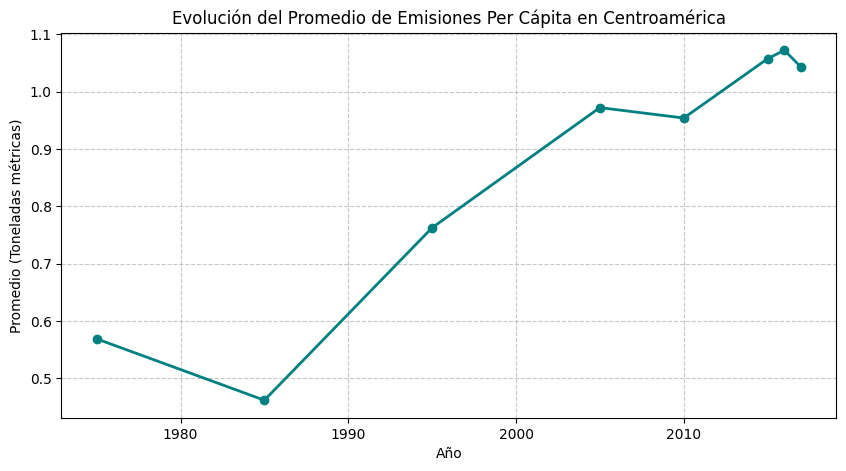

In [15]:
# 5.1 Construye aquí el gráfico de líneas
import matplotlib.pyplot as plt

# --- Gráfico 1: Evolución del Promedio Per Cápita en Centroamérica ---
plt.figure(figsize=(10, 5))
plt.plot(reporte_promedio_centroamerica['anio'], 
        reporte_promedio_centroamerica['promedio_por_anio'], 
        marker='o', linestyle='-', color='teal', linewidth=2)

plt.title('Evolución del Promedio de Emisiones Per Cápita en Centroamérica')
plt.xlabel('Año')
plt.ylabel('Promedio (Toneladas métricas)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Lectura del gráfico 1
Escribe aquí 1 oración explicando por qué este gráfico es útil y qué muestra.

Elegí un gráfico de líneas porque es la herramienta ideal para representar series de tiempo, permitiendo ver claramente la tendencia ascendente o descendente de las emisiones a lo largo de las décadas.


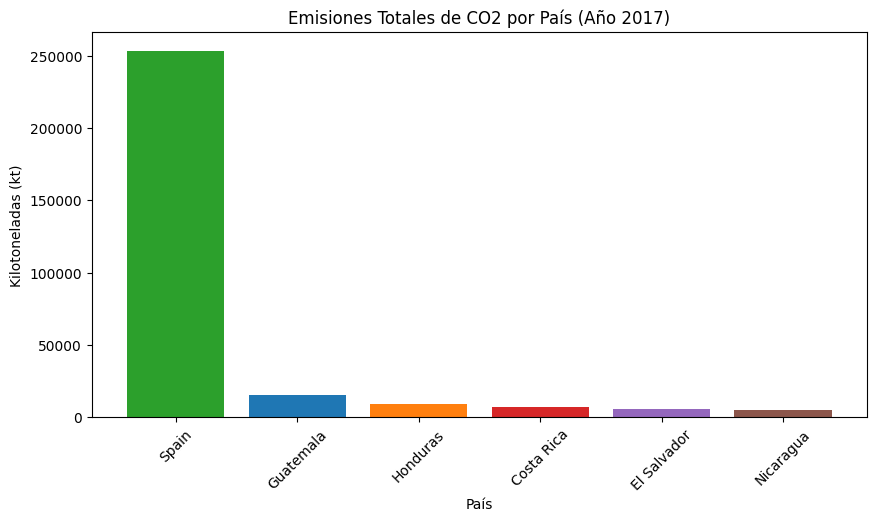

In [16]:
# --- Gráfico 2: Comparativa de Emisiones Totales 2017 ---
plt.figure(figsize=(10, 5))
plt.bar(comparacion_2017['pais'], 
        comparacion_2017['valor'], 
        color=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728', '#9467bd', '#8c564b'])

plt.title('Emisiones Totales de CO2 por País (Año 2017)')
plt.xlabel('País')
plt.ylabel('Kilotoneladas (kt)')
plt.xticks(rotation=45)
plt.show()

### Lectura del gráfico 2
Escribe aquí 1 oración explicando por qué este gráfico es útil y qué muestra.


Elegí un gráfico de barras porque facilita la comparación directa de magnitudes entre categorías independientes, permitiendo identificar visualmente la enorme brecha entre España y los países centroamericanos.

### Interpretación de gráficos del Bloque 5
Escribe aquí tus 3 a 4 líneas.

Al analizar ambos gráficos en conjunto, se observa que, aunque el promedio per cápita regional muestra una tendencia de crecimiento constante, la escala absoluta de emisiones de Centroamérica sigue siendo mínima frente a naciones europeas como España. Esto sugiere que el impacto ambiental regional está más ligado al desarrollo de infraestructura y transporte que a una producción industrial pesada masiva. El contraste visual confirma que la responsabilidad climática debe evaluarse tanto por el crecimiento interno como por la magnitud global.

---
## Bloque 6 — Informe final crítico (20 pts)

### Objetivo
Cerrar el examen con una síntesis crítica basada en evidencia, no solo con una lista de resultados.

### Debes redactar un informe de 6 a 8 líneas que incluya obligatoriamente
- **2 hallazgos numéricos concretos**
- **1 limitación real del análisis**
- **1 comparación explícita entre emisiones totales y per cápita**
- **1 conclusión final** sobre el comportamiento de las emisiones en los países analizados
- **1 recomendación o advertencia final** basada en tus datos
- **coherencia clara** entre lo que exploraste, calculaste, graficaste y concluiste

### Regla importante
No describas solo resultados: explica qué significan.

### Nivel esperado
- **No logrado:** texto genérico sin cifras ni juicio analítico.
- **Inicial:** incluye alguna cifra, pero la conclusión es débil o desconectada.
- **Intermedio:** presenta hallazgos, limitación y conclusión coherente.
- **Logrado:** sintetiza, compara, limita e interpreta con evidencia concreta y criterio, y además propone una recomendación o advertencia defendible.


### Informe final crítico
El análisis revela que, para el año 2017, la brecha industrial es masiva: mientras España registró 253,364.31 kt de CO2, Costa Rica apenas alcanzó 7,750.48 kt, evidenciando escalas de impacto ambiental totalmente distintas. Una limitación real de este estudio es la ausencia de datos demográficos anuales, lo que impide determinar si el aumento en las emisiones se debe a ineficiencia tecnológica o simplemente al crecimiento poblacional. Al contrastar las métricas, se observa que países con emisiones totales bajas pueden presentar una intensidad per cápita alta, demostrando que el volumen absoluto no siempre refleja la eficiencia energética individual. Se concluye que las emisiones en Centroamérica mantienen una tendencia creciente, aunque su peso global sigue siendo marginal frente a potencias europeas. Como advertencia final, se recomienda no legislar basándose únicamente en valores totales, ya que la métrica per cápita es la que realmente identifica los focos de consumo desmedido en la población.



---
## Criterios de corrección visibles para el estudiante
- Se descontarán puntos si usas nombres distintos a los exigidos y eso dificulta la revisión.
- Se descontarán puntos si respondes con texto sin evidencia numérica.
- Se descontarán puntos si usas `pandas` para resolver lo que se pidió explícitamente con Python base.
- Se descontarán puntos si confundes emisiones totales con emisiones per cápita.
- Se descontarán puntos si generas gráficos sin título o sin ejes rotulados.
- Se reconocerá crédito parcial cuando el razonamiento sea correcto aunque el resultado final no sea exacto.
- Se valorará especialmente la coherencia entre exploración, análisis, gráficos e informe final.


## Checklist final de entrega
- [ ] Cargué y exploré el archivo correctamente.
- [ ] Expliqué qué representa una fila del dataset.
- [ ] Expliqué la diferencia entre emisiones totales y per cápita.
- [ ] Creé `df_trabajo`.
- [ ] Creé `df_totales_es` y `df_per_capita_es`.
- [ ] Creé `renombrar_columnas_es(df)` y `separar_por_tipo(df, tipo_emision)`.
- [ ] Escribí una `prediccion_inicial`.
- [ ] Creé `registros_totales`.
- [ ] Creé `resumen_pais(registros, pais)`.
- [ ] Construí `reporte_centroamerica_base`.
- [ ] Comparé mi predicción con la evidencia.
- [ ] Construí `reporte_total_centroamerica`.
- [ ] Construí `reporte_promedio_centroamerica`.
- [ ] Construí `conversiones_costa_rica`.
- [ ] Creé `comparar_paises(df, paises)`.
- [ ] Construí `comparacion_2017` y la usé como evidencia visible.
- [ ] Contrasté emisiones totales vs per cápita con un ejemplo concreto.
- [ ] Generé los 2 gráficos.
- [ ] Expliqué por qué cada gráfico era útil.
- [ ] Escribí el informe final crítico con recomendación o advertencia.
